Loading Expert Models...
✓ Expert 1 (URL) loaded
✓ Expert 2 (Text) loaded

✅ Both expert models loaded!

Loading datasets...
UTF-8 failed, trying latin-1 encoding...
URL dataset: 722802 samples
Text dataset: 150355 samples
Combined dataset: 20000 samples
Label distribution:
label
0.0    12995
1.0     7005
Name: count, dtype: int64

Training set: 16000 samples
Test set: 4000 samples

Training Gating Network...
  Epoch 1/5 - Sample 1000/16000 - Loss: 0.3147
  Epoch 1/5 - Sample 2000/16000 - Loss: 0.3138
  Epoch 1/5 - Sample 3000/16000 - Loss: 0.3136
  Epoch 1/5 - Sample 4000/16000 - Loss: 0.3148
  Epoch 1/5 - Sample 5000/16000 - Loss: 0.3167
  Epoch 1/5 - Sample 6000/16000 - Loss: 0.3133
  Epoch 1/5 - Sample 7000/16000 - Loss: 0.3148
  Epoch 1/5 - Sample 8000/16000 - Loss: 0.3389
  Epoch 1/5 - Sample 9000/16000 - Loss: 0.3607
  Epoch 1/5 - Sample 10000/16000 - Loss: 0.3176
  Epoch 1/5 - Sample 11000/16000 - Loss: 0.3152
  Epoch 1/5 - Sample 12000/16000 - Loss: 0.3212
  Epoch 1/5 - Sample

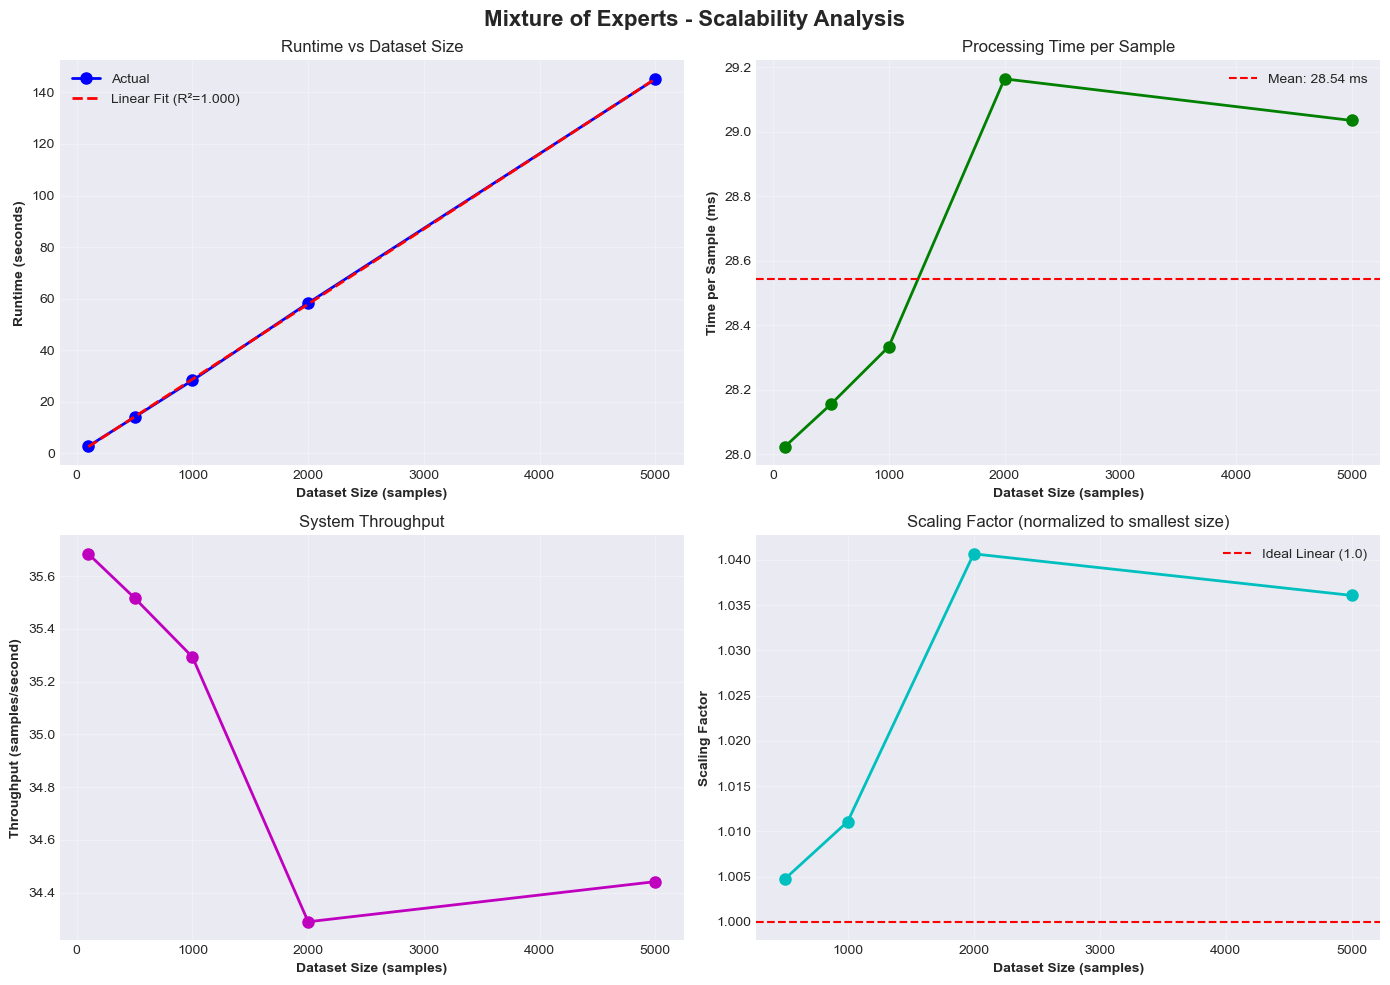


📄 Report saved to: moe_scalability_report.txt


In [19]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LinearRegression
from scipy.sparse import csr_matrix
import re
import time
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: Define URLFeatures Class
# ============================================================================

class URLFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, urls):
        urls = np.array(urls).reshape(-1)
        feats = np.array([
            [
                len(u),
                u.count('-'),
                u.count('@'),
                u.count('?'),
                u.count('='),
                u.count('.'),
                int(u.startswith("https")),
                int(u.count("//") > 1)
            ]
            for u in urls
        ])
        return csr_matrix(feats)

# ============================================================================
# STEP 2: Load Expert Models
# ============================================================================

print("Loading Expert Models...")

URL_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\URL_Expert-20251210T060216Z-1-001\URL_Expert\Notebook and Model\url_expert_1.pkl"
expert_1 = joblib.load(URL_MODEL_PATH)
print("✓ Expert 1 (URL) loaded")

TEXT_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\distilbert_phishing_model"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
expert_2 = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)
expert_2.eval()
print("✓ Expert 2 (Text) loaded")

print("\n✅ Both expert models loaded!\n")

# ============================================================================
# STEP 3: Load and Prepare Training Data
# ============================================================================

print("Loading datasets...")

# Load URL dataset
df_url = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv")
df_url = df_url[['url', 'label']].copy()
df_url['text'] = ""  # Add empty text column

# Load text dataset (with encoding fix)
try:
    df_text = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv")
except UnicodeDecodeError:
    print("UTF-8 failed, trying latin-1 encoding...")
    df_text = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv", encoding='latin-1')
except:
    print("Trying ISO-8859-1 encoding...")
    df_text = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv", encoding='ISO-8859-1')

df_text = df_text[['label', 'text']].copy()
df_text['url'] = ""  # Add empty url column

print(f"URL dataset: {len(df_url)} samples")
print(f"Text dataset: {len(df_text)} samples")

# Combine datasets
df_combined = pd.concat([df_url, df_text], ignore_index=True)
df_combined = df_combined.dropna()

# Sample data to make training faster
df_combined = df_combined.sample(n=min(20000, len(df_combined)), random_state=42)

print(f"Combined dataset: {len(df_combined)} samples")
print(f"Label distribution:\n{df_combined['label'].value_counts()}\n")

# Split into train and test
X = df_combined[['text', 'url']]
y = df_combined['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples\n")

# ============================================================================
# STEP 4: Helper Functions
# ============================================================================

def preprocess_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def calculate_phrase_score(text, phrase_dict):
    if not text:
        return 0.0
    text_lower = text.lower()
    score = 0.0
    for phrase, weight in phrase_dict.items():
        if phrase in text_lower:
            score += weight
    return min(score, 1.0)

def extract_gating_features(text, url, phrase_score):
    url_present = 1 if (url and not pd.isna(url) and url != "") else 0
    message_length = len(text.split()) if text else 0
    emoji_count = len(re.findall(r'[^\w\s,]', text)) if text else 0
    hashtag_count = text.count('#') if text else 0
    url_count = len(re.findall(r'http\S+', text)) if text else 0
    
    if text and len(text) > 0:
        capital_ratio = sum(1 for c in text if c.isupper()) / len(text)
    else:
        capital_ratio = 0.0
    
    embedding_summary = 0.0
    
    features = np.array([
        url_present,
        phrase_score,
        message_length,
        emoji_count,
        hashtag_count,
        url_count,
        capital_ratio,
        embedding_summary
    ], dtype=np.float32)
    
    return features

phrase_dict = {
    'urgent': 0.3,
    'verify account': 0.5,
    'suspended': 0.4,
    'click here': 0.3,
    'confirm your': 0.4,
    'congratulations': 0.3,
    'winner': 0.4,
    'limited time': 0.3,
    'act now': 0.3,
    'security alert': 0.5,
    'claim': 0.3,
    'prize': 0.3,
    'free': 0.2,
    'bonus': 0.2,
}

# ============================================================================
# STEP 5: Define Gating Network
# ============================================================================

class GatingNetwork(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_experts=2):
        super(GatingNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_experts)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        weights = self.softmax(x)
        return weights

# ============================================================================
# STEP 6: Train Gating Network
# ============================================================================

def train_gating_network(X_train, y_train, expert_1, expert_2, phrase_dict, num_epochs=5):
    gating_net = GatingNetwork(input_size=8, hidden_size=64, num_experts=2)
    optimizer = optim.Adam(gating_net.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    gating_net.train()
    
    print("Training Gating Network...")
    print("=" * 70)
    
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        indices = np.random.permutation(len(X_train))
        
        for i, idx in enumerate(indices):
            text = X_train.iloc[idx]['text']
            url = X_train.iloc[idx]['url']
            label = y_train.iloc[idx]
            
            text = preprocess_text(text)
            phrase_score = calculate_phrase_score(text, phrase_dict)
            
            # Get URL expert prediction
            if url and not pd.isna(url) and url != "":
                try:
                    url_df = pd.DataFrame({'url': [url]})
                    url_probs = expert_1.predict_proba(url_df)[0]
                except:
                    url_probs = np.array([0.5, 0.5])
            else:
                url_probs = np.array([0.5, 0.5])
            
            # Get text expert prediction
            if text:
                try:
                    inputs = tokenizer(text, return_tensors='pt', padding=True, 
                                     truncation=True, max_length=128)
                    with torch.no_grad():
                        outputs = expert_2(**inputs)
                        text_probs = torch.softmax(outputs.logits, dim=1)[0].numpy()
                except:
                    text_probs = np.array([0.5, 0.5])
            else:
                text_probs = np.array([0.5, 0.5])
            
            url_probs_tensor = torch.FloatTensor(url_probs).unsqueeze(0)
            text_probs_tensor = torch.FloatTensor(text_probs).unsqueeze(0)
            
            gating_features = extract_gating_features(text, url, phrase_score)
            gating_input = torch.FloatTensor(gating_features).unsqueeze(0)
            
            expert_weights = gating_net(gating_input)
            
            expert_preds = torch.stack([url_probs_tensor, text_probs_tensor], dim=1)
            weights_expanded = expert_weights.unsqueeze(2)
            final_probs = (expert_preds * weights_expanded).sum(dim=1)
            
            label_tensor = torch.LongTensor([label])
            loss = criterion(final_probs, label_tensor)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            pred = torch.argmax(final_probs, dim=1)
            correct += (pred == label_tensor).sum().item()
            total += 1
            
            if (i + 1) % 1000 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} - Sample {i+1}/{len(X_train)} - Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / len(X_train)
        accuracy = correct / total
        print(f"✓ Epoch {epoch+1}/{num_epochs} Complete - Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
        print("-" * 70)
    
    print("\n✅ Gating Network Training Complete!\n")
    return gating_net

# Train the gating network
gating_net = train_gating_network(X_train, y_train, expert_1, expert_2, phrase_dict, num_epochs=5)

# ============================================================================
# STEP 7: Evaluation Function
# ============================================================================

def evaluate_moe(X_test, y_test, expert_1, expert_2, gating_net, phrase_dict):
    print("Evaluating Mixture of Experts...")
    
    predictions = []
    confidences = []
    
    gating_net.eval()
    
    for idx in range(len(X_test)):
        text = X_test.iloc[idx]['text']
        url = X_test.iloc[idx]['url']
        
        text = preprocess_text(text)
        phrase_score = calculate_phrase_score(text, phrase_dict)
        
        if url and not pd.isna(url) and url != "":
            try:
                url_df = pd.DataFrame({'url': [url]})
                url_probs = expert_1.predict_proba(url_df)[0]
            except:
                url_probs = np.array([0.5, 0.5])
        else:
            url_probs = np.array([0.5, 0.5])
        
        if text:
            try:
                inputs = tokenizer(text, return_tensors='pt', padding=True, 
                                 truncation=True, max_length=128)
                with torch.no_grad():
                    outputs = expert_2(**inputs)
                    text_probs = torch.softmax(outputs.logits, dim=1)[0].numpy()
            except:
                text_probs = np.array([0.5, 0.5])
        else:
            text_probs = np.array([0.5, 0.5])
        
        gating_features = extract_gating_features(text, url, phrase_score)
        gating_input = torch.FloatTensor(gating_features).unsqueeze(0)
        
        with torch.no_grad():
            expert_weights = gating_net(gating_input)
        
        final_probs = (expert_weights[0, 0].item() * url_probs + 
                      expert_weights[0, 1].item() * text_probs)
        
        predictions.append(1 if final_probs[1] > 0.5 else 0)
        confidences.append(max(final_probs))
    
    cm = confusion_matrix(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, confidences)
    pr_auc = average_precision_score(y_test, confidences)
    
    print("\n" + "=" * 70)
    print("📊 EVALUATION RESULTS")
    print("=" * 70)
    print("\n=== Confusion Matrix ===")
    print(f"TN: {cm[0,0]:6}  |  FP: {cm[0,1]:6}")
    print(f"FN: {cm[1,0]:6}  |  TP: {cm[1,1]:6}")
    
    print("\n=== Performance Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print("=" * 70)
    
    return predictions, confidences

# Evaluate on test set
evaluate_moe(X_test, y_test, expert_1, expert_2, gating_net, phrase_dict)

# ============================================================================
# STEP 8: Save Gating Network
# ============================================================================

print("\nSaving gating network...")
torch.save(gating_net.state_dict(), 'gating_network.pth')
print("✅ Gating network saved as 'gating_network.pth'\n")

# ============================================================================
# STEP 9: SCALABILITY TEST CLASS
# ============================================================================

class ScalabilityTester:
    """
    Tests runtime scalability of the MoE system across different dataset sizes.
    Acceptable: O(n) linear growth
    Red flag: O(n²) or worse polynomial growth
    """
    
    def __init__(self, expert_1, expert_2, gating_net, phrase_dict, tokenizer):
        self.expert_1 = expert_1
        self.expert_2 = expert_2
        self.gating_net = gating_net
        self.phrase_dict = phrase_dict
        self.tokenizer = tokenizer
        self.results = []
    
    def generate_test_data(self, n_samples):
        """Generate synthetic test data"""
        urls = [
            f"https://example{i}.com/path?id={i}" if i % 2 == 0 else ""
            for i in range(n_samples)
        ]
        texts = [
            f"Urgent! Verify your account now. Click here {i}" if i % 2 == 0 
            else f"Hello, this is a normal message {i}"
            for i in range(n_samples)
        ]
        labels = [i % 2 for i in range(n_samples)]
        
        return pd.DataFrame({'text': texts, 'url': urls}), np.array(labels)
    
    def time_inference(self, X, y):
        """Time the inference process"""
        start_time = time.time()
        
        for idx in range(len(X)):
            self._predict_single(X.iloc[idx]['text'], X.iloc[idx]['url'])
        
        elapsed = time.time() - start_time
        return elapsed
    
    def _predict_single(self, text, url):
        """Single prediction"""
        text = preprocess_text(text) if text else ""
        phrase_score = calculate_phrase_score(text, self.phrase_dict)
        
        # URL Expert
        if url and url.strip():
            try:
                url_df = pd.DataFrame({'url': [url]})
                url_probs = self.expert_1.predict_proba(url_df)[0]
            except:
                url_probs = np.array([0.5, 0.5])
        else:
            url_probs = np.array([0.5, 0.5])
        
        # Text Expert
        if text:
            try:
                inputs = self.tokenizer(text, return_tensors='pt', padding=True, 
                                 truncation=True, max_length=128)
                with torch.no_grad():
                    outputs = self.expert_2(**inputs)
                    text_probs = torch.softmax(outputs.logits, dim=1)[0].numpy()
            except:
                text_probs = np.array([0.5, 0.5])
        else:
            text_probs = np.array([0.5, 0.5])
        
        # Gating Network
        gating_features = extract_gating_features(text, url, phrase_score)
        gating_input = torch.FloatTensor(gating_features).unsqueeze(0)
        
        self.gating_net.eval()
        with torch.no_grad():
            expert_weights = self.gating_net(gating_input)
        
        final_probs = (expert_weights[0, 0].item() * url_probs + 
                      expert_weights[0, 1].item() * text_probs)
        
        return final_probs
    
    def run_scalability_test(self, test_sizes=[100, 500, 1000, 2000, 5000, 10000]):
        """Run scalability tests across different dataset sizes"""
        print("\n" + "=" * 80)
        print("SCALABILITY TEST - RUNTIME vs DATASET SIZE")
        print("=" * 80)
        print(f"\n{'Size':<10} {'Time (s)':<12} {'Time/Sample (ms)':<20} {'Throughput (samples/s)':<20}")
        print("-" * 80)
        
        for size in test_sizes:
            X, y = self.generate_test_data(size)
            runtime = self.time_inference(X, y)
            time_per_sample = (runtime / size) * 1000  # ms
            throughput = size / runtime
            
            self.results.append({
                'size': size,
                'runtime': runtime,
                'time_per_sample': time_per_sample,
                'throughput': throughput
            })
            
            print(f"{size:<10} {runtime:<12.3f} {time_per_sample:<20.3f} {throughput:<20.1f}")
        
        print("-" * 80)
        return self.analyze_results()
    
    def analyze_results(self):
        """Analyze if growth is linear (O(n)) or polynomial"""
        df = pd.DataFrame(self.results)
        
        # Fit linear model
        X = df['size'].values.reshape(-1, 1)
        y = df['runtime'].values
        
        linear_model = LinearRegression()
        linear_model.fit(X, y)
        
        r_squared = linear_model.score(X, y)
        slope = linear_model.coef_[0]
        intercept = linear_model.intercept_
        
        # Check for polynomial growth
        X_poly = np.column_stack([X, X**2])
        poly_model = LinearRegression()
        poly_model.fit(X_poly, y)
        r_squared_poly = poly_model.score(X_poly, y)
        
        print("\n" + "=" * 80)
        print("COMPLEXITY ANALYSIS")
        print("=" * 80)
        print(f"\nLinear Model (O(n)): runtime = {slope:.6f} * size + {intercept:.3f}")
        print(f"R² Score (Linear): {r_squared:.6f}")
        print(f"R² Score (Polynomial): {r_squared_poly:.6f}")
        
        if r_squared > 0.95:
            status = "✅ EXCELLENT - Nearly perfect linear scaling"
        elif r_squared > 0.90:
            status = "✅ GOOD - Acceptable linear scaling"
        elif r_squared > 0.85:
            status = "⚠️  ACCEPTABLE - Mostly linear with some variance"
        else:
            status = "❌ POOR - Non-linear growth detected"
        
        print(f"\nScalability Status: {status}")
        
        avg_time_per_sample = df['time_per_sample'].mean()
        std_time_per_sample = df['time_per_sample'].std()
        
        print(f"\nAverage Time per Sample: {avg_time_per_sample:.3f} ms")
        print(f"Std Dev Time per Sample: {std_time_per_sample:.3f} ms")
        
        print("\n" + "-" * 80)
        print("PREDICTIONS FOR LARGER DATASETS")
        print("-" * 80)
        for pred_size in [50000, 100000, 500000]:
            pred_time = linear_model.predict([[pred_size]])[0]
            pred_minutes = pred_time / 60
            print(f"{pred_size:>8,} samples: {pred_time:>8.1f}s ({pred_minutes:>6.1f} min)")
        
        print("=" * 80)
        
        return {
            'linear_r2': r_squared,
            'poly_r2': r_squared_poly,
            'slope': slope,
            'intercept': intercept,
            'avg_time_per_sample': avg_time_per_sample,
            'status': status
        }
    
    def plot_results(self, save_path='scalability_plot.png'):
        """Generate visualization of scalability results"""
        df = pd.DataFrame(self.results)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Mixture of Experts - Scalability Analysis', fontsize=16, fontweight='bold')
        
        # Plot 1: Runtime vs Dataset Size
        ax1 = axes[0, 0]
        ax1.plot(df['size'], df['runtime'], 'bo-', linewidth=2, markersize=8, label='Actual')
        
        X = df['size'].values.reshape(-1, 1)
        y = df['runtime'].values
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        ax1.plot(df['size'], y_pred, 'r--', linewidth=2, label=f'Linear Fit (R²={model.score(X, y):.3f})')
        
        ax1.set_xlabel('Dataset Size (samples)', fontweight='bold')
        ax1.set_ylabel('Runtime (seconds)', fontweight='bold')
        ax1.set_title('Runtime vs Dataset Size')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot 2: Time per Sample
        ax2 = axes[0, 1]
        ax2.plot(df['size'], df['time_per_sample'], 'go-', linewidth=2, markersize=8)
        ax2.axhline(y=df['time_per_sample'].mean(), color='r', linestyle='--', 
                    label=f'Mean: {df["time_per_sample"].mean():.2f} ms')
        ax2.set_xlabel('Dataset Size (samples)', fontweight='bold')
        ax2.set_ylabel('Time per Sample (ms)', fontweight='bold')
        ax2.set_title('Processing Time per Sample')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Plot 3: Throughput
        ax3 = axes[1, 0]
        ax3.plot(df['size'], df['throughput'], 'mo-', linewidth=2, markersize=8)
        ax3.set_xlabel('Dataset Size (samples)', fontweight='bold')
        ax3.set_ylabel('Throughput (samples/second)', fontweight='bold')
        ax3.set_title('System Throughput')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Scaling Factor
        ax4 = axes[1, 1]
        scaling_factors = []
        for i in range(1, len(df)):
            factor = (df.iloc[i]['runtime'] / df.iloc[i]['size']) / \
                    (df.iloc[0]['runtime'] / df.iloc[0]['size'])
            scaling_factors.append(factor)
        
        ax4.plot(df['size'][1:], scaling_factors, 'co-', linewidth=2, markersize=8)
        ax4.axhline(y=1.0, color='r', linestyle='--', label='Ideal Linear (1.0)')
        ax4.set_xlabel('Dataset Size (samples)', fontweight='bold')
        ax4.set_ylabel('Scaling Factor', fontweight='bold')
        ax4.set_title('Scaling Factor (normalized to smallest size)')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n Plot saved to: {save_path}")
        plt.show()
    
    def generate_report(self, filename='scalability_report.txt'):
        """Generate detailed text report"""
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write("MIXTURE OF EXPERTS - SCALABILITY TEST REPORT\n")
            f.write("=" * 80 + "\n\n")
            
            f.write("TEST CONFIGURATION\n")
            f.write("-" * 80 + "\n")
            f.write(f"Test Sizes: {[r['size'] for r in self.results]}\n")
            f.write(f"Number of Tests: {len(self.results)}\n\n")
            
            f.write("DETAILED RESULTS\n")
            f.write("-" * 80 + "\n")
            f.write(f"{'Size':<10} {'Runtime(s)':<12} {'ms/sample':<15} {'samples/s':<15}\n")
            f.write("-" * 80 + "\n")
            for r in self.results:
                f.write(f"{r['size']:<10} {r['runtime']:<12.3f} {r['time_per_sample']:<15.3f} {r['throughput']:<15.1f}\n")
            
            df = pd.DataFrame(self.results)
            X = df['size'].values.reshape(-1, 1)
            y = df['runtime'].values
            linear_model = LinearRegression()
            linear_model.fit(X, y)
            r_squared = linear_model.score(X, y)
            
            f.write("\n" + "=" * 80 + "\n")
            f.write("CONCLUSION\n")
            f.write("=" * 80 + "\n")
            f.write(f"\nLinear R² Score: {r_squared:.6f}\n")
            
            if r_squared > 0.85:
                f.write("Status: ✅ The system demonstrates acceptable linear scalability.\n")
            else:
                f.write("Status: ❌ The system shows poor scalability characteristics.\n")
        
        print(f"\n📄 Report saved to: {filename}")

# ============================================================================
# STEP 10: RUN SCALABILITY TEST
# ============================================================================

print("\n" + "=" * 80)
print("STARTING SCALABILITY TEST")
print("=" * 80)

# Initialize tester
tester = ScalabilityTester(expert_1, expert_2, gating_net, phrase_dict, tokenizer)

# Run tests with different sizes
test_sizes = [100, 500, 1000, 2000, 5000]  # Start with smaller sizes
analysis = tester.run_scalability_test(test_sizes)

# Generate visualizations
tester.plot_results('moe_scalability.png')

# Generate report
tester.generate_report('moe_scalability_report.txt')
